In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv(
    "../Data/Processed/clean_nav_history.csv"
)
transactions = pd.read_csv(
    "../Data/Processed/clean_investor_transactions.csv"
)
holdings = pd.read_csv(
    "../Data/Processed/clean_portfolio_holdings.csv"
)
scorecard = pd.read_csv(
    "../Outputs/fund_scorecard.csv"
)

FileNotFoundError: [Errno 2] No such file or directory: '../Outputs/fund_scorecard.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\karan\OneDrive\Desktop\Mutual_Fund_Capstone_Project\Notebooks


In [4]:
os.listdir("..")

['.git',
 'bluestock_mf.db',
 'Dashboard',
 'Data',
 'data_dictionary.md',
 'data_ingestion.py',
 'live_nav_fetch.py',
 'Notebooks',
 'README.md',
 'reports',
 'requirements.txt',
 'sql']

In [5]:
os.listdir("../Outputs")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../Outputs'

In [6]:
os.listdir()

['.ipynb_checkpoints',
 'Day1_Data_Ingestion.ipynb',
 'Day2_Data_Cleaning.ipynb',
 'Day3_EDA_Analysis.ipynb',
 'Day4_Performance_Analytics.ipynb',
 'day6 _Advanced_Analytics.ipynb',
 'Mutual_Fund_Capstone_Project.ipynb']

In [7]:
import os

for root, dirs, files in os.walk(".."):
    for file in files:
        if "scorecard" in file.lower():
            print(os.path.join(root, file))

..\Data\Processed\fund_scorecard.csv
..\reports\top10_fund_scorecard.png


In [9]:
v = pd.read_csv(
    "../Data/Processed/clean_nav_history.csv"
)
transactions = pd.read_csv(
    "../Data/Processed/clean_investor_transactions.csv"
)
holdings = pd.read_csv(
    "../Data/Processed/clean_portfolio_holdings.csv"
)
scorecard = pd.read_csv(
    "../Data/Processed/fund_scorecard.csv"
)

In [12]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [11]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [14]:
scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
0,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.023196,-0.287060,1.000,0.675,1.000,0.5000,0.900,83.3750
1,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,0.000549,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
2,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,0.011455,-0.311719,0.875,0.700,0.975,0.3625,0.925,77.9375
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,0.005104,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
4,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.022830,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500


# Historical VaR and CVaR Analysis

In [16]:
nav["date"] = pd.to_datetime(
    nav["date"]
)
nav = nav.sort_values(
    ["amfi_code","date"]
)
nav["daily_return"] = (
    nav.groupby("amfi_code")
       ["nav"]
       .pct_change()
)

In [17]:
nav[
    ["amfi_code",
     "date",
     "nav",
     "daily_return"]
].head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [18]:
risk_report = []
for fund, data in nav.groupby("amfi_code"):

    returns = data[
        "daily_return"
    ].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    risk_report.append([
        fund,
        var95,
        cvar95
    ])

In [19]:
var_cvar = pd.DataFrame(
    risk_report,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [20]:
var_cvar.to_csv(
    "../Outputs/var_cvar_report.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\Outputs'

In [21]:
var_cvar.to_csv(
    "../Data/Processed/var_cvar_report.csv",
    index=False
)

In [22]:
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [23]:
var_cvar.to_csv(
    "../Data/Processed/var_cvar_report.csv",
    index=False
)

In [24]:
scorecard.columns.tolist()

['amfi_code',
 'scheme_name',
 'return_3yr_pct',
 'expense_ratio_pct',
 'sharpe_ratio',
 'alpha',
 'beta',
 'max_drawdown',
 'return_rank',
 'sharpe_rank',
 'alpha_rank',
 'expense_rank',
 'dd_rank',
 'fund_score']

In [25]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

# Rolling 90-Day Sharpe Ratio

In [27]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [28]:
top5_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

top5_funds[
    ["amfi_code","scheme_name"]
]

,amfi_code,scheme_name
0,119598,SBI Small Cap Fund - Regular Plan - Growth
1,120505,ICICI Pru Midcap Fund - Regular - Growth
2,149324,DSP Small Cap Fund - Regular - Growth
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120843,Kotak Flexicap Fund - Regular - Growth


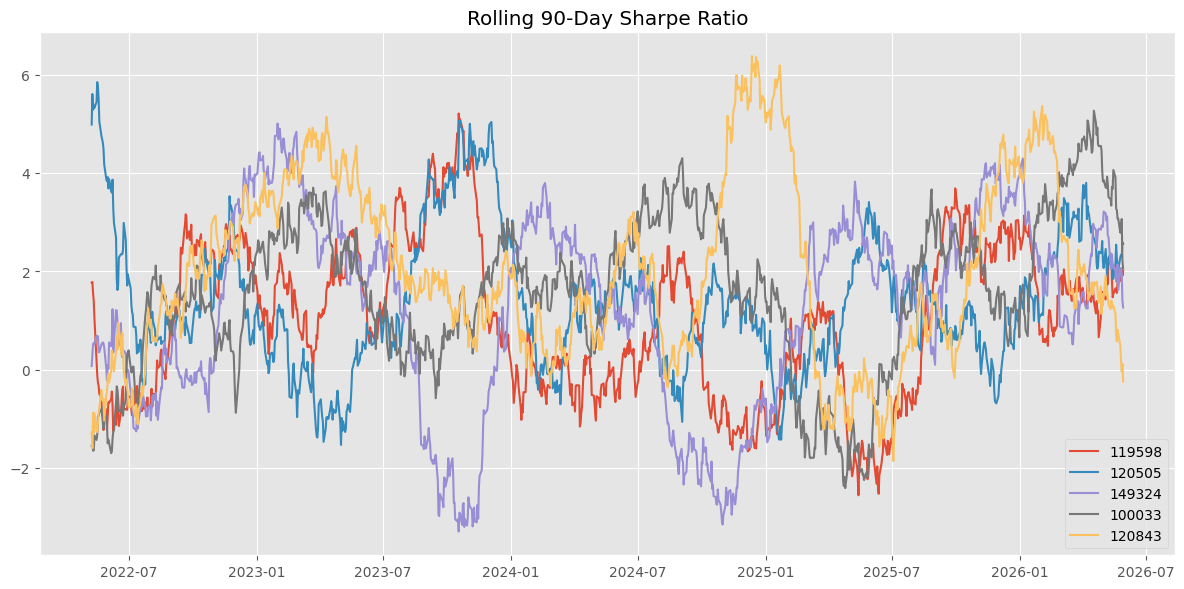

In [29]:
plt.figure(figsize=(12,6))
for fund in top5_funds["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.legend()

plt.tight_layout()

plt.show()

In [30]:
import os
os.makedirs(
    "../reports",
    exist_ok=True
)

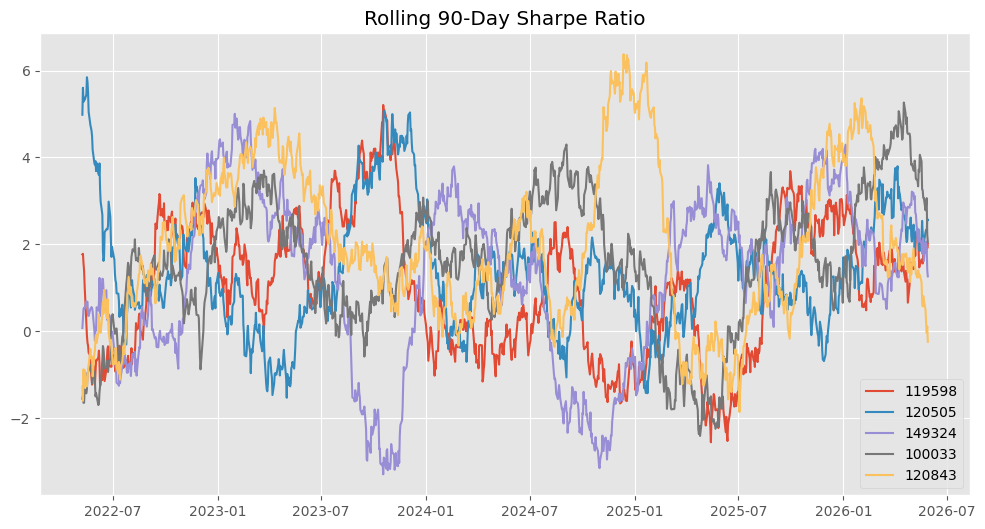

In [31]:
plt.figure(figsize=(12,6))
for fund in top5_funds["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [32]:
transactions.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

# Investor Cohort Analysis

In [34]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [35]:
first_year = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .dt.year
)
first_year.head()

investor_id
INV000001    2024
INV000002    2024
INV000003    2024
INV000004    2024
INV000005    2024
Name: transaction_date, dtype: int32

In [36]:
transactions = transactions.merge(
    first_year.rename("cohort_year"),
    on="investor_id"
)
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [37]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_investment=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        ),
        investors=(
            "investor_id",
            "nunique"
        )
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [38]:
cohort_fund = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="transactions")
)

top_funds = (
    cohort_fund
    .sort_values(
        ["cohort_year","transactions"],
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

top_funds

,cohort_year,amfi_code,transactions
62,2025,119599,12
35,2024,148568,874


In [39]:
cohort_summary.to_csv(
    "../Data/Processed/cohort_analysis.csv",
    index=False
)

# SIP Continuity Analysis

In [41]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [42]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [43]:
sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [44]:
continuity = (
    sip.groupby("investor_id")
    .agg(
        avg_gap_days=(
            "gap_days",
            "mean"
        ),
        sip_count=(
            "transaction_date",
            "count"
        )
    )
    .reset_index()
)

continuity.head()

,investor_id,avg_gap_days,sip_count
0,INV000001,76.0,2
1,INV000002,207.0,3
2,INV000003,238.0,2
3,INV000004,85.4,6
4,INV000005,14.0,3


In [45]:
continuity = continuity[
    continuity["sip_count"] >= 6
]

In [46]:
continuity["risk_flag"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()

,investor_id,avg_gap_days,sip_count,risk_flag
3,INV000004,85.400000,6,At Risk
7,INV000008,70.400000,6,At Risk
9,INV000010,64.800000,6,At Risk
10,INV000011,40.166667,7,At Risk
11,INV000012,57.000000,8,At Risk


In [47]:
continuity["risk_flag"].value_counts()

risk_flag
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [48]:
continuity.to_csv(
    "../Data/Processed/sip_continuity_report.csv",
    index=False
)

In [49]:
cohort_summary.head()

continuity["risk_flag"].value_counts()

risk_flag
At Risk    1332
Healthy      30
Name: count, dtype: int64

# Fund Recommendation Engine

In [52]:
def recommend_funds(risk_level):

    if risk_level == "Low":

        subset = scorecard[
            scorecard["beta"] < 0.8
        ]

    elif risk_level == "Moderate":

        subset = scorecard[
            (scorecard["beta"] >= 0.8)
            &
            (scorecard["beta"] <= 1.1)
        ]

    else:

        subset = scorecard[
            scorecard["beta"] > 1.1
        ]

    return (
        subset
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        [
            [
                "scheme_name",
                "sharpe_ratio",
                "fund_score"
            ]
        ]
        .head(3)
    )

In [53]:
recommend_funds("Low")

,scheme_name,sharpe_ratio,fund_score
7,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,68.7500
4,Kotak Flexicap Fund - Regular - Growth,1.306744,75.2500
9,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,62.6875


In [54]:
recommend_funds("Moderate")

,scheme_name,sharpe_ratio,fund_score


In [55]:
recommend_funds("High")

,scheme_name,sharpe_ratio,fund_score


# Sector Concentration Analysis (HHI)HFGJF

In [56]:
holdings["weight_sq"] = (
    holdings["weight_pct"] / 100
) ** 2

In [57]:
hhi = (
    holdings
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [58]:
hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [59]:
hhi.to_csv(
    "../Data/Processed/hhi_report.csv",
    index=False
)

# Advanced Insights

## Insight 1
Funds with the most negative VaR and CVaR values exhibited significantly higher downside risk during adverse market periods.

## Insight 2
Top-performing funds maintained consistently positive rolling Sharpe Ratios, indicating superior risk-adjusted performance.

## Insight 3
Recent investor cohorts contributed the highest cumulative investment amounts, reflecting growing retail participation in mutual funds.

## Insight 4
SIP continuity analysis identified 1332 at-risk investors versus only 30 healthy investors, indicating potential retention challenges.

## Insight 5
Funds with higher HHI values displayed concentrated portfolios and greater exposure to a smaller number of securities.

In [60]:
hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [61]:
recommend_funds("Moderate")

,scheme_name,sharpe_ratio,fund_score


In [62]:
scorecard["beta"].describe()

count    40.000000
mean     -0.001958
std       0.035194
min      -0.066951
25%      -0.023937
50%      -0.000067
75%       0.017026
max       0.103497
Name: beta, dtype: float64

In [63]:
scorecard.sort_values(
    "beta"
)[
    ["scheme_name","beta"]
].head()

,scheme_name,beta
19,Axis Small Cap Fund - Regular - Growth,-0.066951
5,Axis Midcap Fund - Regular - Growth,-0.066265
14,ABSL Small Cap Fund - Regular - Growth,-0.065289
32,HDFC Top 100 Fund - Regular Plan - Growth,-0.058268
28,UTI Mid Cap Fund - Regular - Growth,-0.042125


In [64]:
scorecard.sort_values(
    "beta",
    ascending=False
)[
    ["scheme_name","beta"]
].head()

,scheme_name,beta
12,Nippon India Small Cap Fund - Regular - Growth,0.103497
11,SBI Small Cap Fund - Direct Plan - Growth,0.062002
18,HDFC Top 100 Fund - Direct Plan - Growth,0.048820
16,ICICI Pru Value Discovery Fund - Regular - Growth,0.041896
31,Kotak Bluechip Fund - Regular - Growth,0.036356


In [65]:
def recommend_funds(risk_level):

    if risk_level == "Low":

        subset = scorecard[
            scorecard["max_drawdown"] > -0.15
        ]

    elif risk_level == "Moderate":

        subset = scorecard[
            scorecard["max_drawdown"] > -0.25
        ]

    else:

        subset = scorecard

    return (
        subset
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        [
            [
                "scheme_name",
                "sharpe_ratio",
                "fund_score"
            ]
        ]
        .head(3)
    )